<h1 align=center style='color:blue; border:1px dotted blue;'>Image Similarity Search in PyTorch</h1>

### STEP 1 — IMPORT LIBRARIES

In [1]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import torchvision.models as models
import torchvision.transforms as transforms

### STEP 2 — LOAD DATASET

In [2]:
DATASET_PATH = "/kaggle/input/images-alike/images/"

image_paths = [
    os.path.join(DATASET_PATH, img)
    for img in os.listdir(DATASET_PATH)
]

### ALGORITHM 1 — CLIP FEATURES
## Load CLIP

In [3]:
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

/opt/conda/lib/python3.7/site-packages/clip/clip.py:24: UserWarning: PyTorch version 1.7.1 or higher is recommended
  warnings.warn("PyTorch version 1.7.1 or higher is recommended")


## Feature Extraction

In [4]:
def clip_embedding(path):
    img = preprocess(Image.open(path)).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = clip_model.encode_image(img)
    return feat.cpu().numpy()

### ALGORITHM 2 — CNN (ResNet Features)

In [5]:
resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def cnn_embedding(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = resnet(img).flatten()

    return feat.cpu().numpy().reshape(1,-1)

### ALGORITHM 3 — COLOR HISTOGRAM

In [6]:
def histogram_embedding(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224,224))

    hist = cv2.calcHist([img], [0,1,2], None,
                        [8,8,8],
                        [0,256,0,256,0,256])
    return hist.flatten().reshape(1,-1)

### STEP 3 — BUILD DATABASE

In [7]:
clip_features = []
cnn_features = []
hist_features = []

for img in image_paths:
    clip_features.append(clip_embedding(img))
    cnn_features.append(cnn_embedding(img))
    hist_features.append(histogram_embedding(img))

clip_features = np.vstack(clip_features)
cnn_features = np.vstack(cnn_features)
hist_features = np.vstack(hist_features)

### STEP 4 — QUERY IMAGE

In [8]:
query_path = image_paths[0]

### STEP 5 — QUERY FEATURES

In [9]:
q_clip = clip_embedding(query_path)
q_cnn = cnn_embedding(query_path)
q_hist = histogram_embedding(query_path)

### STEP 6 — SIMILARITY SEARCH
## CLIP (Cosine)

In [10]:
clip_scores = cosine_similarity(q_clip, clip_features)[0]
clip_top = clip_scores.argsort()[-6:][::-1]

## CNN (Euclidean)

In [11]:
cnn_scores = euclidean_distances(q_cnn, cnn_features)[0]
cnn_top = cnn_scores.argsort()[:6]

### Histogram (Chi-square via Euclidean approx)

In [12]:
hist_scores = euclidean_distances(q_hist, hist_features)[0]
hist_top = hist_scores.argsort()[:6]

### STEP 7 — DISPLAY RESULTS

In [13]:
def show_images(indices, title):
    plt.figure(figsize=(12,5))
    plt.suptitle(title)

    for i, idx in enumerate(indices):
        img = Image.open(image_paths[idx])
        plt.subplot(1,6,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

### FINAL OUTPUT

🔵 CLIP Results


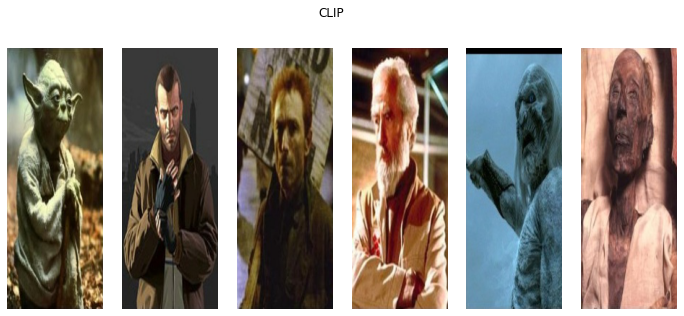

🟢 CNN Results


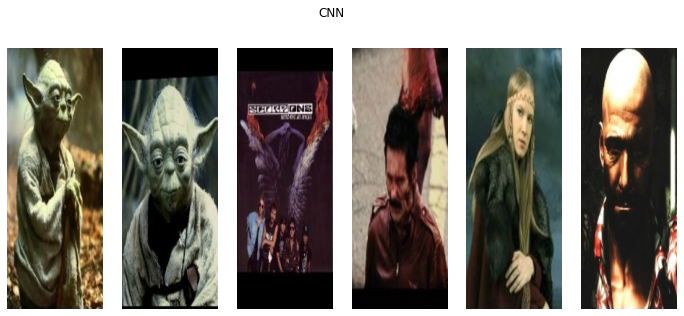

🟣 Histogram Results


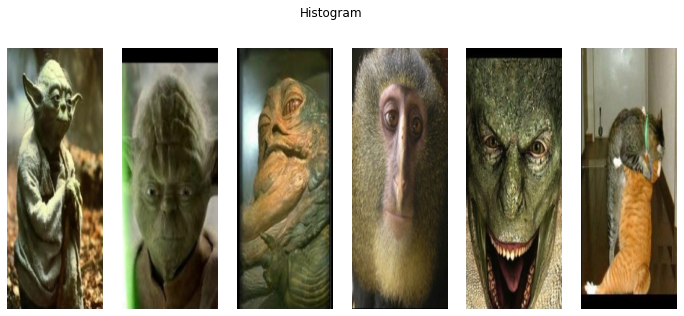

In [14]:
print("🔵 CLIP Results")
show_images(clip_top, "CLIP")

print("🟢 CNN Results")
show_images(cnn_top, "CNN")

print("🟣 Histogram Results")
show_images(hist_top, "Histogram")

